In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , roc_auc_score
from sklearn.metrics import accuracy_score , precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
X = pd.read_pickle('/content/drive/MyDrive/X_selected.pkl')
X.head()

,C13,C14,card6,C4,V294,P_emaildomain,M4,C2,TransactionAmt,V102,...,D2,V308,D3,TransactionAmt_decimal,V279,D1,V97,V285,V287,V292
0,-0.209442,-0.16168,-1.417635,-0.129225,0.002191,-0.273411,0.056240,-0.138502,-0.286720,0.175428,...,-0.246213,-0.135555,-0.106015,0.516594,-0.258524,-0.459809,-0.266897,-0.416013,-0.352825,-0.057757
1,-0.209442,-0.16168,-1.417635,-0.129225,-0.057319,1.224142,-1.455800,-0.138502,-0.477663,-0.124474,...,-0.246213,-0.135555,-0.224910,-0.714202,-0.258524,-0.561340,-0.266897,-0.416013,-0.352825,-0.057757
2,-0.209442,-0.16168,0.703854,-0.129225,-0.057319,-1.459781,-1.455800,-0.138502,-0.332643,-0.124474,...,-0.246213,-0.135555,-0.224910,-0.714202,-0.258524,-0.561340,-0.266897,-0.416013,-0.352825,-0.057757
3,-0.112479,-0.16168,0.703854,-0.129225,2.204061,-0.293405,-1.455800,-0.128778,-0.376149,11.271803,...,-0.161117,1.137497,-0.415141,-0.714202,0.598908,0.250907,15.206661,4.117007,4.661243,-0.057757
4,-0.209442,-0.16168,-1.417635,-0.129225,-0.057319,1.224142,0.812261,-0.138502,-0.376149,-0.124474,...,-0.246213,-0.135555,-0.224910,-0.714202,-0.258524,-0.561340,-0.266897,-0.416013,-0.352825,-0.057757


In [8]:
y = pd.read_pickle('/content/drive/MyDrive/y_selected.pkl')
y.head()

,isFraud
0,0
1,0
2,0
3,0
4,0


In [9]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [10]:
X_train.shape

(115124, 50)

In [22]:
X_test.shape

(28782, 50)

In [12]:
y_train.shape

(115124,)

In [11]:
y_test.shape

(28782,)

In [13]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),

    'Decision Tree' : DecisionTreeClassifier(),

    'Random Forest' : RandomForestClassifier(),

    'Gradient Boosting' : GradientBoostingClassifier(),

    'XGboost' : XGBClassifier(),

    'LightGBM' : LGBMClassifier()
}

In [14]:
results = []
for name , model in models.items():
    model.fit(X_train , y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test , y_pred)
    precision = precision_score(y_test , y_pred)
    recall = recall_score(y_test , y_pred)
    f1= f1_score(y_test , y_pred)


    results.append([name , accuracy , precision , recall , f1])

[LightGBM] [Info] Number of positive: 57534, number of negative: 57590
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12745
[LightGBM] [Info] Number of data points in the train set: 115124, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499757 -> initscore=-0.000973
[LightGBM] [Info] Start training from score -0.000973


In [15]:
results_df = pd.DataFrame(results , columns=['Models' , 'Accuracy' , 'Preision' , 'Recall' , 'FI'])

In [16]:
results_df

,Models,Accuracy,Preision,Recall,FI
0,Logistic Regression,0.771593,0.789121,0.742493,0.765097
1,Decision Tree,0.979327,0.977084,0.981760,0.979417
2,Random Forest,0.993399,0.997205,0.989597,0.993386
3,Gradient Boosting,0.952748,0.968165,0.936473,0.952055
4,XGboost,0.991766,0.997894,0.985644,0.991731
5,LightGBM,0.989751,0.996206,0.983286,0.989704


In [18]:
from sklearn.metrics import confusion_matrix
rf = RandomForestClassifier()
rf.fit(X_train , y_train)
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test , y_pred)
cm

array([[14323,    40],
       [  148, 14271]])

In [19]:
Xgb = XGBClassifier()
Xgb.fit(X_train , y_train)
y_pred = Xgb.predict(X_test)
cm = confusion_matrix(y_test , y_pred)
cm

array([[14333,    30],
       [  207, 14212]])

In [20]:
lgb = LGBMClassifier()
lgb.fit(X_train , y_train)
y_pred = lgb.predict(X_test)
cm = confusion_matrix(y_test , y_pred)
cm

[LightGBM] [Info] Number of positive: 57534, number of negative: 57590
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063300 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12745
[LightGBM] [Info] Number of data points in the train set: 115124, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499757 -> initscore=-0.000973
[LightGBM] [Info] Start training from score -0.000973


array([[14309,    54],
       [  241, 14178]])

In [21]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test , y_pred)

np.float64(0.9897631409607693)

In [22]:
from sklearn.model_selection import cross_val_score

cross_val_score(rf , X , y , cv=5)

array([0.50521159, 0.97126577, 0.97123102, 0.97619958, 0.58580313])

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5)

scores = cross_val_score(rf, X, y, cv=skf)

print(scores)
print(scores.mean())

[0.51403655 0.97672075 0.9756784  0.97779785 0.59021577]
0.806889864587397


In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
params = {
    'n_estimators' : [100  , 200 , 300],
    'max_depth' : [10, 20 ,30],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]

}


In [49]:
rf_cv = RandomizedSearchCV(
    rf,
    param_distributions=params,
    n_iter=5,
    cv=3,
    scoring='f1',
    n_jobs=-1 )
rf_cv.fit(X_train , y_train)
rf_cv.best_score_

np.float64(0.9894279670743177)

In [54]:
best_model = rf_cv.best_estimator_

In [55]:
rf_cv.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_depth': 20}

In [56]:
y_pred = best_model.predict(X_test)

In [57]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

print("F1 Score:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1 Score: 0.9912589239073655
[[14299    64]
 [  187 14232]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     14363
           1       1.00      0.99      0.99     14419

    accuracy                           0.99     28782
   macro avg       0.99      0.99      0.99     28782
weighted avg       0.99      0.99      0.99     28782



In [58]:
print("Train F1:", f1_score(y_train, best_model.predict(X_train)))
print("Test F1:", f1_score(y_test, y_pred))

Train F1: 0.9970129496904092
Test F1: 0.9912589239073655


In [59]:
accuracy_score(y_test , y_pred)

0.9912792717670766

In [60]:
f1_score(y_test , y_pred)

0.9912589239073655

<Axes: >

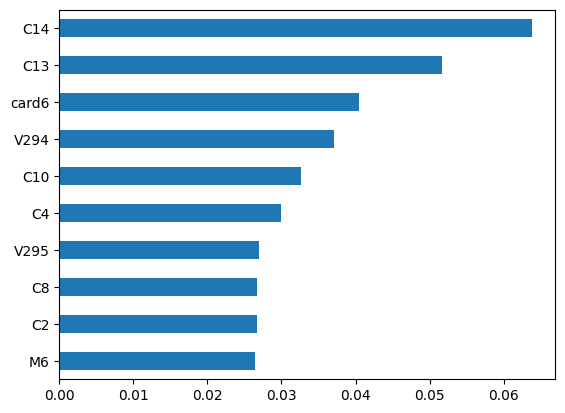

In [62]:
import pandas as pd

feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind="barh")

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
import joblib

joblib.dump(best_model, "/content/drive/MyDrive/fraud_detection_model.pkl")

['/content/drive/MyDrive/fraud_detection_model.pkl']